<a href="https://colab.research.google.com/github/arunpr2313/Machine-learning/blob/main/EXP6_SCENARIO02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelEncoder

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
print("Scenario 2 - 24BAD012")

Scenario 2 - 24BAD012


In [41]:
df = pd.read_csv('churn_boosting.csv')

In [42]:
le = LabelEncoder()

for col in ['ContractType', 'InternetService']:
    df[col] = le.fit_transform(df[col])

In [43]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [45]:
ada = AdaBoostClassifier(n_estimators=50, random_state=42)
ada.fit(X_train, y_train)

gb = GradientBoostingClassifier(n_estimators=50, random_state=42)
gb.fit(X_train, y_train)

GradientBoostingClassifier(n_estimators=50, random_state=42)

Text(0.5, 1.0, 'ROC Curve')

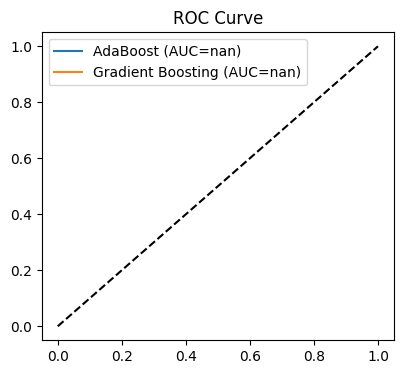

In [46]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)

for model, name in [(ada, 'AdaBoost'), (gb, 'Gradient Boosting')]:
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.2f})')

plt.plot([0,1],[0,1], 'k--')
plt.legend()
plt.title('ROC Curve')

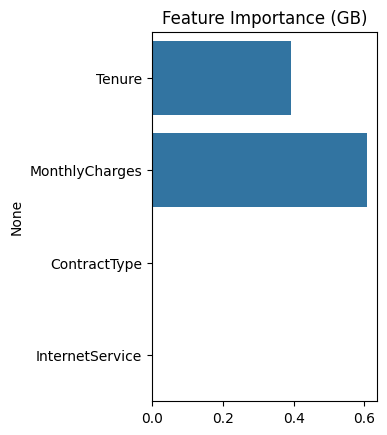

In [47]:
plt.subplot(1, 2, 2)
sns.barplot(x=gb.feature_importances_, y=X.columns)
plt.title('Feature Importance (GB)')

plt.show()